# Scenario playground

Replay any part of the pipeline with different parameters, **without re-running the
rest**. Expensive inputs are loaded once in §0; each scenario section is then a
`PARAMS`-cell + a run-cell + a comparison — change the parameters, re-run two cells.

| Section | Workflow step | Knobs |
|---|---|---|
| §1 | Step 1 · bank distances | `n_points` (furthest-N selection) |
| §2 | Step 1 · hybrid source | `within_year` collapse rule |
| §3 | Step 2 · region split | split `seed` — how much is split luck? |
| §4 | Step 4 · training | LightGBM `learning_rate` × `num_leaves` |
| §5 | Step 5 · prediction | which model drives the 25-year forecast |

Full runs (all steps, persisted + report.html) are the CLI's job:
`uv run python -m src.pipeline --experiment <name> [--resume]`.

> **Metric caveat** — every MAE here inherits the known evaluation issues
> (random split across adjacent regions; see README → Known issues). Numbers are
> comparable *between scenarios*, not trustworthy in absolute terms.

In [1]:
# §0a — bootstrap
import os, sys
from pathlib import Path

_cwd = Path.cwd()
for _c in [_cwd, *_cwd.parents]:
    if (_c / 'src').exists():
        os.chdir(_c)
        sys.path.insert(0, str(_c))
        break

import warnings, logging
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

import geopandas as gpd
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

import src.paths as P
from src.pipeline.config import ExperimentConfig
from src.pipeline.region_split import build_region_split
from src.pipeline.train import FEATS_LGB, TARGET, _prep_lgb
from src.pipeline.run import build_start_points, combine_feature_tables
from src.model.export_utils import load_model_bundle
from src.model.predictor import predict_iterative_ml

CFG = ExperimentConfig(experiment='scenarios')   # paths only — nothing is written
REF = P.DATA_DIR / '03_features' / '20260617a'   # cached reference artefacts
BLUE, ORANGE = '#2a78d6', '#eb6834'
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.color': '#e6e4dd',
                     'axes.spines.top': False, 'axes.spines.right': False})
print('root:', Path.cwd())

root: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie


In [2]:
# §0b — load once (the only slow cell, ~40 s)
%time pts = gpd.read_file(CFG.raw_gpkg, layer='punten_oever', ignore_geometry=True, \
                          columns=['location_id', 'dtm_date', 'dist', 'status'])
ok_pts = pts.loc[pts.status == 'OK', ['location_id', 'dtm_date', 'dist']].rename(columns={'dtm_date': 'year'})
ok_pts['year'] = ok_pts['year'].astype(int)

dpy_ref   = pd.read_parquet(REF / 'dist_per_year.parquet')
split_ref = pd.read_parquet(REF / 'region_split.parquet')
feats_ref = pd.read_parquet(REF / 'region_features.parquet')
inf_ref   = pd.read_parquet(REF / 'region_inference_only.parquet')
inf_feats_ref = pd.read_parquet(REF / 'region_inference_features.parquet')
print(f'{len(ok_pts):,} OK points · reference: {len(feats_ref):,} regions')

CPU times: user 9.18 s, sys: 709 ms, total: 9.89 s
Wall time: 12.2 s


4,078,502 OK points · reference: 7,444 regions


## §1 — Step 1: how many furthest points define "the bank"?

The convention is the mean of the **3 furthest** OK points per (region, year)
(`notebooks/reference/20260311_explore_point_selection.ipynb` has the original
rationale). Vary `n_points` and watch the effect ripple into the target `v_test`.

In [3]:
N_POINTS_SCENARIOS = [1, 3, 5, 10]   # ← change and re-run the next cell

In [4]:
def dist_per_year_for(n):
    top = (ok_pts.sort_values('dist', ascending=False)
                 .groupby(['location_id', 'year'], sort=False).head(n))
    out = top.groupby(['location_id', 'year'])['dist'].mean().rename('dist_m').reset_index()
    return out.sort_values(['location_id', 'year']).reset_index(drop=True)

# sanity: n=3 must reproduce the reference
chk = dist_per_year_for(3).merge(dpy_ref, on=['location_id', 'year'], suffixes=('', '_ref'))
assert np.allclose(chk.dist_m, chk.dist_m_ref), 'n=3 no longer matches the reference!'

rows = []
for n in N_POINTS_SCENARIOS:
    split_n, _ = build_region_split(dist_per_year_for(n), proc_gpkg=CFG.proc_gpkg)
    v = split_n['v_test']
    rows.append({'n_points': n, 'regions': len(split_n), 'v_test std': v.std(),
                 '|v|>2 m/yr': int((v.abs() > 2).sum()), '|v|>10 m/yr': int((v.abs() > 10).sum()),
                 'corr with n=3': split_n['v_test'].corr(split_ref['v_test'])})
scenario_1 = pd.DataFrame(rows).set_index('n_points')
scenario_1.round(3)

,regions,v_test std,|v|>2 m/yr,|v|>10 m/yr,corr with n=3
n_points,,,,,
1,7444,2.285,706,81,0.951
3,7444,2.187,689,74,1.000
5,7444,2.140,674,69,0.982
10,7444,2.078,660,66,0.914


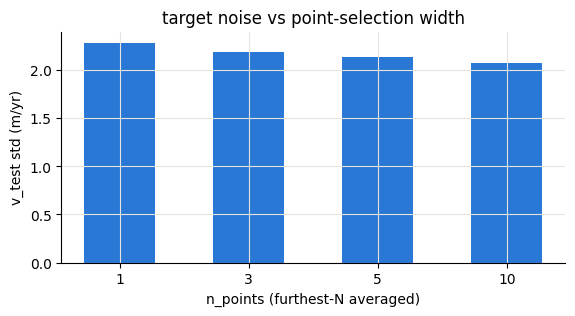

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(scenario_1.index.astype(str), scenario_1['v_test std'], color=BLUE, width=0.55)
ax.set_xlabel('n_points (furthest-N averaged)'); ax.set_ylabel('v_test std (m/yr)')
ax.set_title('target noise vs point-selection width');

## §2 — Step 1 (hybrid): the within-year collapse rule

The hybrid delivery has up to 5 surveys per region per *year*; the rule that
collapses them shapes every velocity. This reproduces the earlier analysis
interactively (skipped automatically if the hybrid file is absent).

In [6]:
WITHIN_YEAR_RULES = ['median', 'mean', 'max']   # ← change and re-run the next cell

In [7]:
HYBRID = P.DATA_DIR / '02_processed/hybrid/hybrid_model_results_20260710.gpkg'
scenario_2 = None
if HYBRID.exists():
    from src.sources import HybridLineSource, ScopeGeometry
    %time hyb_obs = HybridLineSource(HYBRID, geometry=ScopeGeometry(centreline_gpkg=CFG.raw_gpkg)).load()
    rows = []
    for rule in WITHIN_YEAR_RULES:
        s, _ = build_region_split(hyb_obs.to_dist_per_year(within_year=rule), proc_gpkg=CFG.proc_gpkg)
        v = s['v_test']
        rows.append({'rule': rule, 'regions': len(s), 'v_test std': v.std(),
                     '|v|>10': int((v.abs() > 10).sum()), '|v|>50': int((v.abs() > 50).sum())})
    scenario_2 = pd.DataFrame(rows).set_index('rule')
    display(scenario_2.round(2))
    print(f"reference (March points): std={split_ref.v_test.std():.2f}, |v|>50=0")
else:
    print('hybrid delivery not found — section skipped')

CPU times: user 43.4 s, sys: 377 ms, total: 43.8 s
Wall time: 44 s


,regions,v_test std,|v|>10,|v|>50
rule,,,,
median,6824,18.38,1124,216
mean,6824,18.64,1278,216
max,6824,26.16,1482,437


reference (March points): std=2.19, |v|>50=0


## §3 — Step 2: how much of a model's MAE is split luck?

The split is random across adjacent 100 m regions (known issue). Re-drawing it with
different seeds shows how much the headline metric moves with no modelling change at
all — the error bar to keep in mind for every comparison in §4.

In [8]:
SPLIT_SEEDS = [0, 1, 2, 42, 123]   # ← change and re-run the next cell

In [9]:
def quick_eval(feats):
    """Naive-mean and LightGBM test MAE. No early stopping — cleaner than train.py."""
    tr, te = feats[feats.split == 'train'], feats[feats.split == 'test']
    naive = mean_absolute_error(te[TARGET], np.full(len(te), tr[TARGET].mean()))
    m = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31,
                          random_state=42, verbose=-1)
    m.fit(_prep_lgb(tr, FEATS_LGB), tr[TARGET])
    return naive, mean_absolute_error(te[TARGET], m.predict(_prep_lgb(te, FEATS_LGB)))

rows = []
for seed in SPLIT_SEEDS:
    s, _ = build_region_split(dpy_ref, proc_gpkg=CFG.proc_gpkg, random_seed=seed)
    feats_s = feats_ref.drop(columns='split').join(s['split'])
    naive, mae = quick_eval(feats_s)
    rows.append({'seed': seed, 'naive MAE': naive, 'LGBM MAE': mae, 'LGBM beats naive': mae < naive})
scenario_3 = pd.DataFrame(rows).set_index('seed')
scenario_3.round(4)

,naive MAE,LGBM MAE,LGBM beats naive
seed,,,
0,0.7711,0.8833,False
1,0.7333,0.9205,False
2,0.7506,0.8870,False
42,0.7843,0.9379,False
123,0.8683,1.0004,False


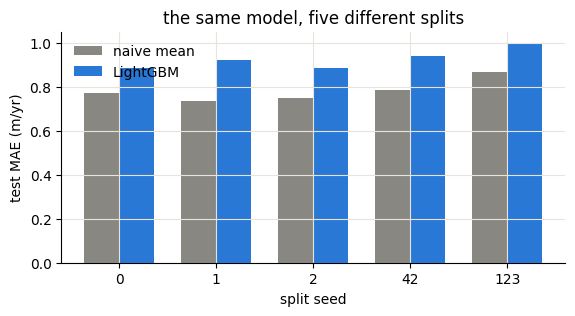

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3))
x = np.arange(len(scenario_3))
ax.bar(x - 0.18, scenario_3['naive MAE'], 0.36, color='#898781', label='naive mean')
ax.bar(x + 0.18, scenario_3['LGBM MAE'], 0.36, color=BLUE, label='LightGBM')
ax.set_xticks(x, scenario_3.index.astype(str)); ax.set_xlabel('split seed')
ax.set_ylabel('test MAE (m/yr)'); ax.legend(frameon=False)
ax.set_title('the same model, five different splits');

## §4 — Step 4: LightGBM hyperparameters

A small grid on the fixed reference split. Compare against the naive baseline and
against the seed-spread from §3 before believing any winner.

In [11]:
LEARNING_RATES = [0.02, 0.05, 0.1]     # ← change and re-run the next cell
NUM_LEAVES     = [15, 31, 63]

In [12]:
tr = feats_ref[feats_ref.split == 'train']; te = feats_ref[feats_ref.split == 'test']
naive_ref = mean_absolute_error(te[TARGET], np.full(len(te), tr[TARGET].mean()))
rows = []
for lr in LEARNING_RATES:
    for leaves in NUM_LEAVES:
        m = lgb.LGBMRegressor(n_estimators=500, learning_rate=lr, num_leaves=leaves,
                              random_state=42, verbose=-1)
        m.fit(_prep_lgb(tr, FEATS_LGB), tr[TARGET])
        rows.append({'learning_rate': lr, 'num_leaves': leaves,
                     'test MAE': mean_absolute_error(te[TARGET], m.predict(_prep_lgb(te, FEATS_LGB)))})
scenario_4 = pd.DataFrame(rows).pivot(index='learning_rate', columns='num_leaves', values='test MAE')
print(f'naive baseline: {naive_ref:.4f}')
scenario_4.round(4)

naive baseline: 0.7843


num_leaves,15,31,63
learning_rate,,,
0.02,0.8389,0.8693,0.9107
0.05,0.8763,0.9379,0.9980
0.10,0.9464,0.9955,1.0536


## §5 — Step 5: which model drives the 25-year forecast?

Rolling prediction on one cluster (fast), once per bundle model. The divergence
between model choices *compounds* over the horizon — this is where a small MAE
difference becomes metres of bank.

In [13]:
CLUSTER   = 'maas1'                     # ← change and re-run the next cell
MODELS    = ['ols', 'ridge_cat', 'lgb']
END_YEAR  = 2050

,median shift by 2050 (m),p90 shift (m)
model,,
ols,3.05,3.09
ridge_cat,-10.14,-7.64
lgb,1.98,5.60


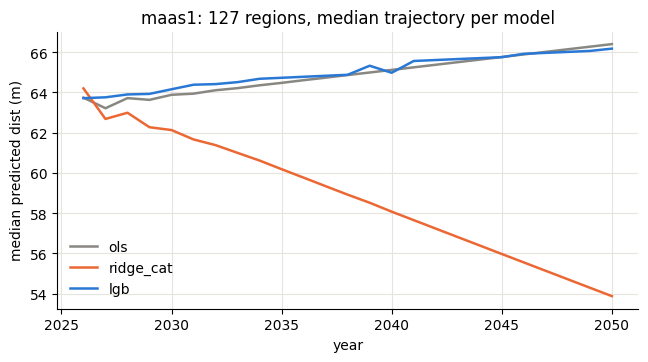

In [14]:
bundle_dir = P.DATA_DIR / '04_model_outputs' / '20260817a'
if not bundle_dir.exists():
    bundle_dir = P.DATA_DIR / '04_model_outputs' / '20260617a'
bundle = load_model_bundle(bundle_dir)

all_feats = combine_feature_tables(feats_ref, inf_feats_ref)
sp = build_start_points(feats_ref, split_ref, inf_feats_ref, inf_ref)
locs = [l for l in all_feats.index if l.startswith(CLUSTER)]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
summary = []
for name, color in zip(MODELS, [ '#898781', ORANGE, BLUE]):
    pred = predict_iterative_ml(bundle, all_feats.loc[locs],
                                {k: v for k, v in sp.items() if k in set(locs)},
                                model_name=name, start_year=2026, end_year=END_YEAR, rolling=True)
    start = pred[pred.year == 2026].set_index('location_id')['predicted_dist_m']
    delta = (pred.set_index('location_id')['predicted_dist_m'] - start).groupby(pred.year.values)
    med = pred.groupby('year')['predicted_dist_m'].median()
    shift = pred[pred.year == END_YEAR].set_index('location_id')['predicted_dist_m'] - start
    summary.append({'model': name, f'median shift by {END_YEAR} (m)': shift.median(),
                    f'p90 shift (m)': shift.quantile(0.9)})
    ax.plot(med.index, med.values, color=color, linewidth=1.8, label=name)
ax.set_xlabel('year'); ax.set_ylabel('median predicted dist (m)')
ax.set_title(f'{CLUSTER}: {len(locs)} regions, median trajectory per model')
ax.legend(frameon=False)
scenario_5 = pd.DataFrame(summary).set_index('model')
scenario_5.round(2)

---
### Adding a scenario

Every knob upstream of a step can be replayed the same way: import the step
function, loop over parameters, compare. `ExperimentConfig` gives the paths;
`--resume` on the CLI gives cached inputs for anything not loaded in §0.